In [66]:
%pip install sympy
%pip install control
%pip install numpy
%pip install matplotlib

%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   --------------- ------------------------ 3.4/8.7 MB 19.9 MB/s eta 0:00:01
   ---------------------------------------  8.7/8.7 MB 23.1 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 22.2 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- ----------------------

In [67]:
import numpy as np
import sympy
import sim
import time
import struct

In [68]:
def connect(port):
    sim.simxFinish(-1)
    clientID = sim.simxStart('192.168.78.219', port, True, True, 2000, 5)
    print(clientID)
    if clientID == 0: 
        print("Conectado a", port)
        return clientID
    else: 
        print("No se pudo conectar")
        return -1
clientID = connect(500)

0
Conectado a 500


In [69]:
#Definición de la trayectoria del carro 
_,Carro = sim.simxGetObjectHandle(clientID, 'Carro', sim.simx_opmode_blocking)

print("Carro:", Carro)



_,pos_carro = sim.simxGetObjectPosition(0, Carro, -1, sim.simx_opmode_blocking)
_,ori_carro = sim.simxGetObjectOrientation(0, Carro, -1, sim.simx_opmode_blocking)
print("Posición de Objeto1:", pos_carro)
print("Orientación de Objeto1:", ori_carro)

Pos = 2,-3.5,0.2
Ori = 0,0,0
Ori = np.array(Ori) * np.pi / 180  # Convertir a radianes
sim.simxSetObjectPosition(0, Carro, -1, Pos, sim.simx_opmode_blocking)
sim.simxSetObjectOrientation(0, Carro, -1, Ori, sim.simx_opmode_blocking)


Carro: 40
Posición de Objeto1: [1.999353051185608, -3.5024917125701904, 0.23999959230422974]
Orientación de Objeto1: [-5.78457438678015e-05, 3.0324119393299043e-07, -0.00039638811722397804]


0

DATOS DEL SENSOR

Formato original de los datos recibidos: bytearray(b'\xbf\xc2\xed?|\xbbE\xc0\xea\x05\x90?d5\xec?\x16\xd1D\xc0\x85\x04\x90?\x82\x1c\xea?I\x94C\xc0X\xff\x8f?\xa9N\xe7?\xfa\xecA\xc0\xf0\x01\x90?\x9e\x1a\xe3?Zr?\xc0\x86\x02\x90?\xea\xc8t\xc0Y\xa4j@\xa4NO>!\xb2\xd4\xc0!\xd7\xdf@\x07BP>\x83\xbe\xed?\xfc\xbdE\xc0\xfb\x05\x90?\xa50\xec?\x08\xd4D\xc0\x9a\x04\x90?\x1f\x17\xea?\xdd\x97C\xc0q\xff\x8f?\x82H\xe7?s\xf1A\xc0\r\x02\x90?\x82\x13\xe3?Gx?\xc0\xac\x02\x90?\xca8u\xc08\xc3i@joO>\xba\xee\xd4\xc0K\x15\xdf@\xfaoP>H\xba\xed?|\xc0E\xc0\r\x06\x90?\xe7+\xec?\xf9\xd6D\xc0\xae\x04\x90?\xbd\x11\xea?p\x9bC\xc0\x89\xff\x8f?\\B\xe7?\xeb\xf5A\xc0*\x02\x90?g\x0c\xe3?3~?\xc0\xd0\x02\x90?9\xa9u\xc0;\xe3h@\xc5\x8dO>h*\xd5\xc0\xe9R\xde@7\xa0P>\r\xb6\xed?\xfb\xc2E\xc0\x1d\x06\x90?*\'\xec?\xea\xd9D\xc0\xc1\x04\x90?\\\x0c\xea?\x02\x9fC\xc0\xa1\xff\x8f?7<\xe7?b\xfaA\xc0G\x02\x90?N\x05\xe3?\x1d\x84?\xc0\xf4\x02\x90?\xcb\x18v\xc0\xb4\x02h@t\xadO>\xf9e\xd5\xc0\xec\x90\xdd@\xe9\xcfP>"\xb1\xed?\x11\xc5E\xc0\xdd\x05\x90

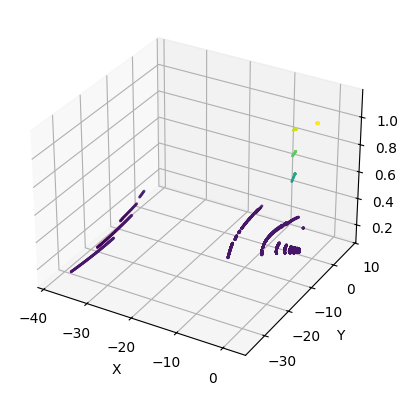

In [70]:
_, lidar_handle = sim.simxGetObjectHandle(clientID, 'VelodyneVPL16', sim.simx_opmode_blocking)
# Inicio del envío de datos del LIDAR
sim.simxGetStringSignal(clientID, 'VelodyneVPL16', sim.simx_opmode_streaming)

# Lectura de datos del LIDAR 
for i in range(50):
    _, data = sim.simxGetStringSignal(clientID, 'VelodyneVPL16', sim.simx_opmode_buffer)
    if data:
        #Convertir los datos de bytes a puntos
        points = struct.unpack('f' * (len(data) // 4), data)
        print(f"Formato original de los datos recibidos: {data}")
        print(f"Puntos recibidos: {points}")
        points = np.array(points).reshape(-1, 3) # Reorganiza los datos para obtener las coordenadas x, y, z
        print("Datos LIDAR recibidos:")
        print(points)
        break
    time.sleep(0.05)
else:
    print("No se recibieron datos del LIDAR.")

sim.simxFinish(clientID)
print("Conexión cerrada")


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Supongamos que ya tienes "points" como matriz Nx3
x, y, z = points[:,0], points[:,1], points[:,2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=z, cmap='viridis', s=1)  # nube de puntos
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()


#Tareas
# 1. Determinar la cantidad de puntos recibidos por el LIDAR.
# 2. Verficar a qué correspondan los puntos recibidos.
# 3. Tratar de recibir de manera continua los datos del LIDAR.

Cantidad de puntos recibidos: 8254


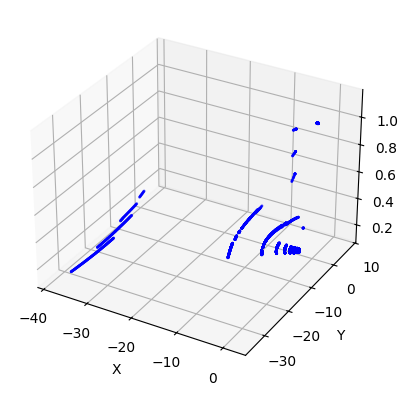

In [71]:
points = np.array(points).reshape(-1, 3)
print("Cantidad de puntos recibidos:", points.shape[0])

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x, y, z = points[:,0], points[:,1], points[:,2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=1, c='blue')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


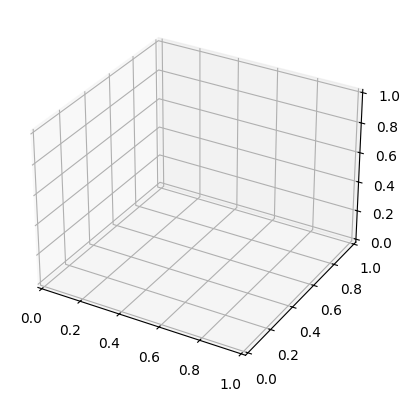

In [72]:
import matplotlib.pyplot as plt

plt.ion()  # modo interactivo
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i in range(200):  # leer 200 frames
    _, data = sim.simxGetStringSignal(clientID, 'VelodyneVPL16', sim.simx_opmode_buffer)
    if data:
        points = struct.unpack('f' * (len(data) // 4), data)
        points = np.array(points).reshape(-1, 3)
        print("Frame", i, "con", points.shape[0], "puntos")
        
        # Visualización rápida (limpiar y volver a graficar)
        ax.clear()
        ax.scatter(points[:,0], points[:,1], points[:,2], s=1, c='red')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        plt.pause(0.01)  # refresca la ventana
    time.sleep(0.05)

plt.ioff()  # desactiva modo interactivo
plt.show()   # última visualización


In [73]:
from sklearn.cluster import DBSCAN

# Parámetros: eps = distancia máxima entre puntos del mismo cluster
clustering = DBSCAN(eps=0.5, min_samples=5).fit(points[:, :2])  # solo x,y
labels = clustering.labels_  # -1 = ruido

# Agrupar puntos por objeto
for label in set(labels):
    if label == -1:  # ruido
        continue
    objeto = points[labels == label]
    print(f"Objeto {label}: {objeto.shape[0]} puntos")

centroides = []
for label in set(labels):
    if label == -1: continue
    cluster = points[labels == label]
    centroid = cluster.mean(axis=0)  # promedio x,y,z
    centroides.append(centroid)

    
ax.clear()
for label in set(labels):
    if label == -1: continue
    cluster = points[labels == label]
    ax.scatter(cluster[:,0], cluster[:,1], cluster[:,2], s=2)


Objeto 0: 4049 puntos
Objeto 1: 13 puntos
Objeto 2: 985 puntos
Objeto 3: 59 puntos
Objeto 4: 114 puntos
Objeto 5: 610 puntos
Objeto 6: 32 puntos
Objeto 7: 45 puntos
Objeto 8: 84 puntos
Objeto 9: 374 puntos
Objeto 10: 354 puntos
Objeto 11: 334 puntos
Objeto 12: 160 puntos
Objeto 13: 313 puntos
Objeto 14: 563 puntos
Objeto 15: 165 puntos


CONTROL

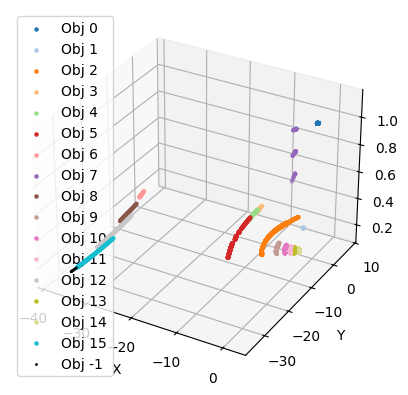

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# --- Supongamos que ya tienes tus puntos LiDAR en la variable `points` ---
# points = np.array([...]).reshape(-1, 3)   # x,y,z

# 1. Aplicar clustering con DBSCAN (solo en X,Y para ignorar altura)
clustering = DBSCAN(eps=0.5, min_samples=10).fit(points[:, :2])
labels = clustering.labels_  # Cada punto recibe un label (-1 = ruido)

# 2. Preparar colores para cada cluster
unique_labels = set(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

# 3. Graficar cada cluster con un color distinto
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

#Le pone colorcitos

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Ruido (puntos sueltos)
        col = "k"  # negro
        size = 1
    else:
        col = color
        size = 5
    
    cluster = points[labels == label]
    ax.scatter(cluster[:, 0], cluster[:, 1], cluster[:, 2], s=size, c=[col], label=f"Obj {label}")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()


Omega: [-6.96950802  8.05113276  5.95091962 -4.86929488]
Omega: [-4.40224299 -7.20808202 -5.66150231 -5.94882269]
Omega: [ 2.21120836 -0.74407268 -0.7344956   2.20163128]
Omega: [ -6.93491    -13.94953071 -14.09103256  -6.79340815]
Omega: [ 9.04980742 13.10953788 11.26879213 10.89055318]
Omega: [19.1003038  10.16940645 11.53831737 17.73139288]
Omega: [21.80310322 11.36799044 11.70100617 21.4700875 ]
Omega: [4.58079629 4.4503924  4.71395326 4.31723544]
Omega: [ 1.22038693 20.48227788 20.03801737  1.66464744]
Omega: [-0.98304804 -3.97875986 -5.96990059  1.00809269]
Omega: [ 8.86382566 12.39607303 13.26074503  7.99915366]
Omega: [-4.52275984 -0.34819078 -2.00510375 -2.86584688]
Omega: [-0.859382   27.32920997 28.53604785 -2.06621988]
Omega: [17.74552328  1.02162204  0.90662245 17.86052287]
Omega: [11.74720042 18.90032572 20.24838136 10.39914479]
Omega: [10.36538272 -8.2254723  -7.58495406  9.72486447]
Omega: [5.83579827 3.46893798 4.57322881 4.73150745]
Omega: [19.3363944  -4.14981386 -2.

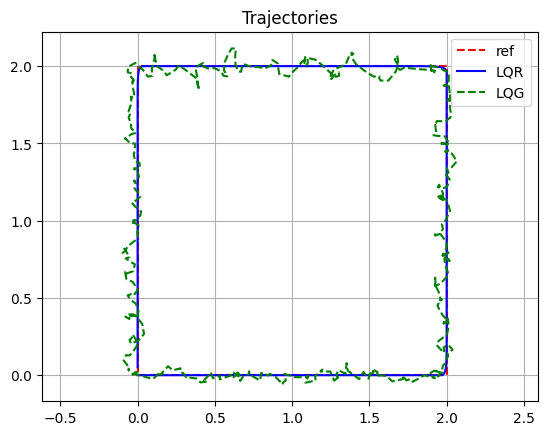

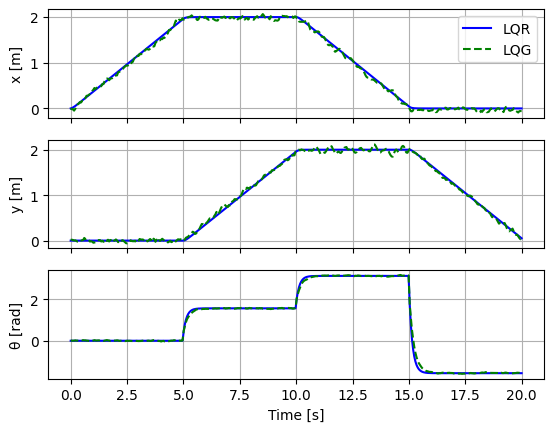

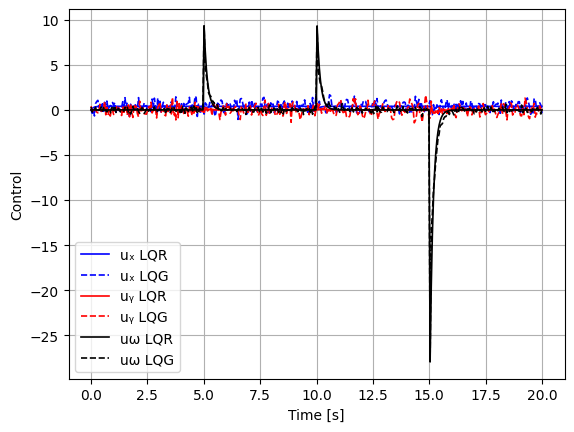

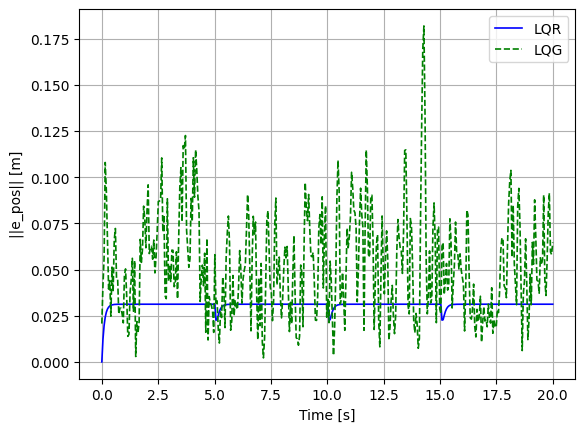

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from control import dlqr, dlqe
from numpy.linalg import pinv

#Verificar si hay giros y el trazado de la ruta

_, joint_fl = sim.simxGetObjectHandle(clientID, 'FL', sim.simx_opmode_blocking)
_, joint_rl = sim.simxGetObjectHandle(clientID, 'RL', sim.simx_opmode_blocking)
_, joint_rr = sim.simxGetObjectHandle(clientID, 'RR', sim.simx_opmode_blocking)
_, joint_fr = sim.simxGetObjectHandle(clientID, 'FR', sim.simx_opmode_blocking)
wheelJoints = [joint_fl, joint_rl, joint_rr, joint_fr]

# -------------------- 1) PARAMETERS & GAINS --------------------
r_wheel = 0.064
l       = 0.1025
J = (1/r_wheel) * np.array([
    [ 1, -1, -(l+l)],
    [ 1,  1,  (l+l)],
    [ 1,  1, -(l+l)],
    [ 1, -1,  (l+l)],
])
J_pinv = pinv(J)

dt = 0.05
tf = 20.0
N  = int(tf/dt)
t  = np.linspace(0, tf, N)

Ad = np.eye(3)
Bd = dt*np.eye(3)
Cd = np.eye(3)

Q = np.diag([10.,10.,5.])
R = np.eye(3)*0.1
K,_,_ = dlqr(Ad, Bd, Q, R)

Qw = np.diag([0.01,0.01,0.005])
Rv = np.diag([0.005,0.005,0.002])
L,_,_ = dlqe(Ad, np.eye(3), Cd, Qw, Rv)  # G = I, not Bd

# -------------------- 2) TRAJECTORY --------------------
def square_traj(tf, dt):
    N = int(tf/dt)
    traj = np.zeros((3,N))
    L = 2.0
    for k in range(N):
        tau = k*dt
        if   tau <  tf/4:
            traj[0,k] = L*(tau)/(tf/4)
        elif tau <  tf/2:
            traj[0,k] = L; traj[1,k] = L*(tau-tf/4)/(tf/4); traj[2,k]=np.pi/2
        elif tau < 3*tf/4:
            traj[0,k] = L - L*(tau-tf/2)/(tf/4); traj[1,k]=L; traj[2,k]=np.pi
        else:
            traj[0,k] = 0; traj[1,k] = L - L*(tau-3*tf/4)/(tf/4); traj[2,k] = -np.pi/2
    return traj

target = square_traj(tf, dt)

# -------------------- 3) STATE & LOGS --------------------
x_lqr  = np.zeros(3)
x_lqg  = np.zeros(3)
xhat   = np.zeros(3)

traj_lqr = np.zeros((3,N))
traj_lqg = np.zeros((3,N))
u_lqr    = np.zeros((3,N))
u_lqg    = np.zeros((3,N))

# -------------------- 4) KINEMATICS UTILITY --------------------
def body_vel(u):
    # here J_pinv@J = I, so body_vel = u
    return u.copy()

# -------------------- 5) SIMULATION --------------------
for k in range(N):
    x_ref = target[:,k]

    # -- LQR (true-state) ---------------------------------
    e_glob = x_ref - x_lqr
    yaw    = x_lqr[2]
    Rth    = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                       [np.sin(yaw),  np.cos(yaw), 0],
                       [0           ,  0           , 1]])
    e_body = Rth.T @ e_glob
    u      = K @ e_body
    v_b    = body_vel(u)
    Rbw    = Rth[:2,:2]
    x_lqr[0:2] += dt*(Rbw @ v_b[0:2])
    x_lqr[2]   += dt*v_b[2]

    traj_lqr[:,k] = x_lqr
    u_lqr[:,k]    = u

    # -- LQG (estimate-based) -----------------------------
    # 1) measurement
    y = x_lqg + np.random.multivariate_normal(np.zeros(3), Rv)

    # 2) observer predict+update using **u2** (not u)
    # we'll compute u2 below, so we do a two-step:
    # predict with last u2, but on first iter u2==u, it's ok
    try:
        prev_u2
    except NameError:
        prev_u2 = u
    xhat = Ad@xhat + Bd@prev_u2 + L@(y - Cd@xhat)

    # 3) compute u2 using **estimated yaw**
    yaw_hat = xhat[2]
    Rth_hat = np.array([[np.cos(yaw_hat), -np.sin(yaw_hat), 0],
                        [np.sin(yaw_hat),  np.cos(yaw_hat), 0],
                        [0              ,  0              , 1]])
    e_glob2 = x_ref - xhat
    e_body2 = Rth_hat.T @ e_glob2
    u2      = K @ e_body2

    # 4) plant under u2
    v_b2 = body_vel(u2)
    x_lqg[0:2] += dt*(Rth[:2,:2] @ v_b2[0:2])  # still world from true yaw
    x_lqg[2]   += dt*v_b2[2]

    traj_lqg[:,k] = x_lqg
    u_lqg[:,k]    = u2
    prev_u2       = u2
    
    #Simulación 
    omega = J @ v_b2
    print(f"Omega: {omega}")
    sim.simxSetJointTargetVelocity(clientID, joint_fl, omega[0], sim.simx_opmode_oneshot)
    sim.simxSetJointTargetVelocity(clientID, joint_fr, omega[1], sim.simx_opmode_oneshot)
    sim.simxSetJointTargetVelocity(clientID, joint_rl, omega[2], sim.simx_opmode_oneshot)
    sim.simxSetJointTargetVelocity(clientID, joint_rr, omega[3], sim.simx_opmode_oneshot)

# -------------------- 6) PLOTS --------------------
plt.figure()
plt.plot(target[0], target[1], 'r--', label='ref')
plt.plot(traj_lqr[0], traj_lqr[1], 'b-',  label='LQR')
plt.plot(traj_lqg[0], traj_lqg[1], 'g--', label='LQG')
plt.axis('equal'); plt.grid(); plt.legend(); plt.title('Trajectories')

fig, axs = plt.subplots(3,1,sharex=True)
labs = ['x [m]','y [m]','θ [rad]']
for i in range(3):
    axs[i].plot(t, traj_lqr[i],  'b-')
    axs[i].plot(t, traj_lqg[i],  'g--')
    axs[i].set_ylabel(labs[i]); axs[i].grid(True)
if True: axs[0].legend(['LQR','LQG'])
axs[2].set_xlabel('Time [s]')

plt.figure()
plt.plot(t, u_lqr[0],'b-', t, u_lqg[0],'b--',
         t, u_lqr[1],'r-', t, u_lqg[1],'r--',
         t, u_lqr[2],'k-', t, u_lqg[2],'k--', linewidth=1.2)
plt.legend(['uₓ LQR','uₓ LQG','uᵧ LQR','uᵧ LQG','uω LQR','uω LQG'])
plt.xlabel('Time [s]'); plt.ylabel('Control'); plt.grid()

err_lqr = np.linalg.norm(traj_lqr[0:2] - target[0:2], axis=0)
err_lqg = np.linalg.norm(traj_lqg[0:2] - target[0:2], axis=0)
plt.figure()
plt.plot(t, err_lqr,'b-', t, err_lqg,'g--', linewidth=1.2)
plt.legend(['LQR','LQG']); plt.xlabel('Time [s]'); plt.ylabel('||e_pos|| [m]'); plt.grid()

plt.show()


In [75]:
wheelJoints = [joint_fl, joint_rl, joint_rr, joint_fr]

def Mov(clientID, joint_fr, joint_fl, joint_rl, joint_rr, vel):
    for i in range(20):
        if i < 5:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, -vel, sim.simx_opmode_blocking)
            time.sleep(1)
        elif i < 10:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, -vel, sim.simx_opmode_blocking)
            time.sleep(1)
        elif i < 15:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, vel, sim.simx_opmode_blocking)
            time.sleep(1)
        else:
            sim.simxSetJointTargetVelocity(clientID, joint_rr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fr, -vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_fl, vel, sim.simx_opmode_blocking)
            sim.simxSetJointTargetVelocity(clientID, joint_rl, vel, sim.simx_opmode_blocking)
            time.sleep(1)
Mov(clientID, joint_fr, joint_fl, joint_rl, joint_rr, 3.0)

#Ya mueve la llanta, mirar cómo puedo hacer que haga el cuadrado y después incorporar el control. Además, ver cómo se puede incorporar en una función.